# Problem B: Solve Pressure Field in 2D Heterogeneous Porous Media

Consider a square domain $\Omega = [0,1]^2$ representing a heterogeneous porous medium composed of two distinct material phases with significantly different permeabilities, for instance, high-permeability sandstone inclusions embedded in a low-permeability mudstone matrix. Such heterogeneous structures arise frequently in subsurface flow engineering, including groundwater modeling, hydrocarbon reservoir simulation, and fuel cell design. Near the interface between the two phases, the pressure gradient exhibits sharp transitions, making this a classical benchmark for testing the robustness of PDE solvers under non-smooth coefficients.

The permeability field $\mu(x)$ is defined as:

$$
\mu(x) =
\begin{cases}
\mu_1 = 10, & x \in \Omega_1 \quad \text{(high-permeability phase, e.g., sandstone)} \\
\mu_2 = 2,  & x \in \Omega_2 \quad \text{(low-permeability phase, e.g., mudstone)}
\end{cases}
$$

The specific two-phase microstructure (i.e., the geometric distribution of $\Omega_1$ and $\Omega_2$) is provided in the dataset. The pressure field $u(x)$ satisfies the following Darcy flow equation:

$$
-\nabla \cdot \left(\mu(x)\,\nabla u\right) = f, \quad x \in \Omega \tag{1}
$$

where
- $u(x):$ pressure field in the porous medium
- $\mu(x):$ spatially varying permeability field
- $f = 0:$ source term (no internal source/sink)
- $\Omega = [0,1]^2:$ square computational domain

The boundary conditions are prescribed as follows, driving fluid flow from the high-pressure inlet on the left to the low-pressure outlet on the right:

$$
g_D(x) =
\begin{cases}
1, & x_1 = 0 \quad \text{(left boundary, high-pressure inlet)} \\
0, & x_1 = 1 \quad \text{(right boundary, low-pressure outlet)} \\
\text{linear interpolation}, & x_2 = 0 \text{ or } 1 \quad \text{(top and bottom boundaries)}
\end{cases}
$$

## Task: Solve the pressure field $u(x)$

In this task, the permeability field $\mu(x)$ is provided as a $128 \times 128$ pixel matrix — that is, the domain is subdivided into $128 \times 128$ cells, each with a constant permeability value. Using this permeability field, apply a suitable method introduced in the lecture to solve for the pressure field $u(x)$ in the heterogeneous porous medium.

### The Goals
- Please select a suitable deep learning method for solving this forward problem to compute the pressure field $u(x)$, and explain the reason for using it.
- Report your setups for the implementation, such as network structure, activation function, optimizer (with learning rate), epoch (with batch size), loss weights, and other tricks that are used for improvement.
- Compute the $L^2$ relative error (on the testing dataset) at each training epoch and plot the `Error vs. epoch` curve (and report the final error). The $L^2$ relative error between the prediction $u_\text{pred}$ and the reference $u_\text{true}$ is defined as follows:

$$
\text{error} = \sqrt{\frac{\sum_i^n \left| u_\text{pred}(x_i) - u_\text{true}(x_i) \right|^2}{\sum_i^n \left| u_\text{true}(x_i) \right|^2}}
$$

- Plot the predicted solution (and the ground truth reference) and the pointwise absolute error using separate figures with `matplotlib`.

### Dataset

The permeability field and the reference solution are provided in the dataset `ProblemB_dataset.h5`:

- `mu_field`: the permeability field $\mu(x)$, represented as a $128 \times 128$ pixel matrix, where each cell has a constant permeability value (available for training)
- `x_test`: the locations where the reference solution is evaluated (Used for computing error and should **not** be used for training)
- `u_test`: the reference pressure field values (used for computing error and should **not** be used for training)
- Link to dataset: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

x_test: torch.Size([16384, 2]) u_test: torch.Size([128, 128]) mu_field: torch.Size([128, 128])


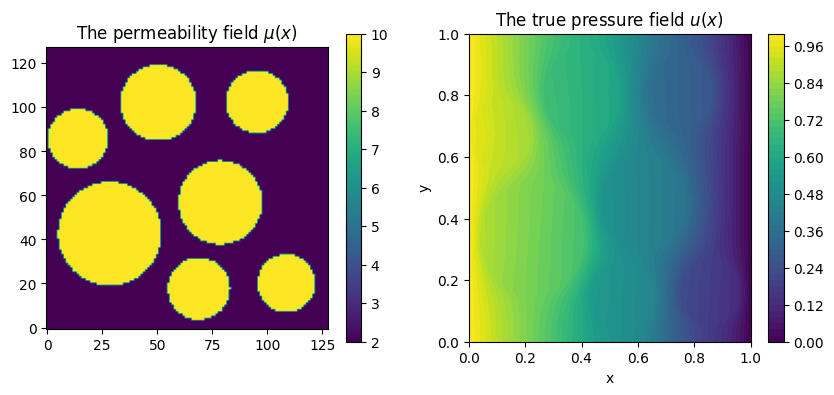

In [3]:
import numpy as np
import torch
import h5py
import matplotlib.pyplot as  plt

# ################################# The testing dataset
with h5py.File('Datasets\ProblemB_dataset.h5', 'r') as f:
    x_test = torch.tensor(np.array(f['x_test']), dtype=torch.float32)
    u_test = torch.tensor(np.array(f['u_test']), dtype=torch.float32) # Should not be used for training !!!
    mu_field = torch.tensor(np.array(f['mu_field']), dtype=torch.float32)
print('x_test:', x_test.shape, 'u_test:', u_test.shape, 'mu_field:', mu_field.shape)
#
def fun_mu(x, mu=mu_field, resolution=128):
    '''The material property field (get values of material field on any given position x)
    Input:
        x: size(N, 2)
    '''
    mu = mu.reshape(1,-1).to(x)
    delta = 1./(resolution-1)
    #
    x_loc = torch.floor(x[...,0] / delta + 0.5).int()
    y_loc = torch.floor(x[...,1] / delta + 0.5).int()
    loc = y_loc * resolution + x_loc
    #
    mu_new = mu[torch.arange(mu.shape[0]).unsqueeze(1), loc]
    
    return mu_new.T

mu = fun_mu(x_test)

# ##################################
fig, axes = plt.subplots(1, 2, figsize=(10,4))
#
cntr = axes[0].imshow(mu.reshape(128,128), origin='lower')
axes[0].set_title(r'The permeability field $\mu(x)$')
plt.colorbar(cntr)
#
cntr = axes[1].contourf(x_test[:,0].reshape(128, 128), x_test[:,1].reshape(128, 128), u_test, levels=50)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title(r'The true pressure field $u(x)$')
plt.colorbar(cntr)
plt.show()

### Additional Imports and Device Setup

In [4]:
import torch
from torchsummary import summary
from torch.autograd import grad, Variable
from torch.utils.data import Dataset, DataLoader

from tqdm import trange

from scipy.interpolate import griddata

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # Use CUDA if available, else use CPU
dataType = torch.float32    # sets the PyTorch tensor type to 32-bit floating point

np.random.seed(1234)    # fixes NumPy’s random seed, reproducible result
torch.manual_seed(1234) # fixes PyTorch’s random seed, reproducible result

print(f"device: {device}")

device: cuda


### Grid and Collocation points

Size of test points: torch.Size([16384, 2])
Size of test solution: torch.Size([128, 128])
Size of mu field: torch.Size([128, 128])


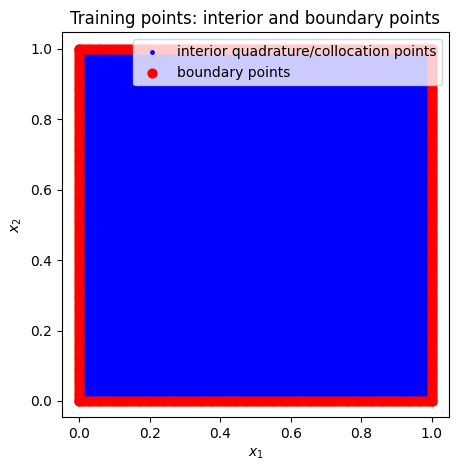

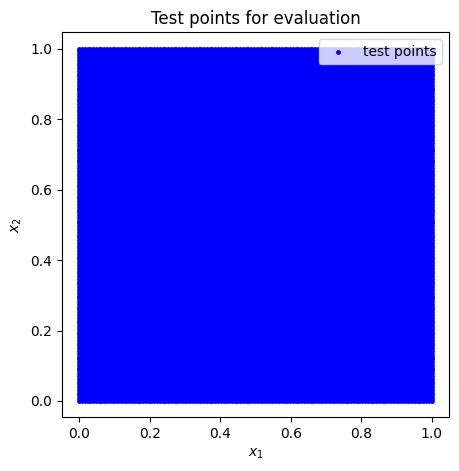

In [5]:
lb = [0., 0] 
ub = [1., 1.] 

n = 128         # To match the resolution of the given permeability field
nc = n**2       # number of collocation points

# --- The Boundary Points (x,y=0) and (x,y=1) ---
# Lower boundary
x_lw = np.vstack((
    np.linspace(lb[0], ub[0], n),
    lb[1] * np.ones(n)
)).T

# Upper boundary
x_up = np.vstack((
    np.linspace(lb[0], ub[0], n),
    ub[1] * np.ones(n)
)).T

# Left boundary
x_lt = np.vstack((
    lb[0] * np.ones(n),
    np.linspace(lb[1], ub[1], n)
)).T

# Right boundary
x_rt = np.vstack((
    ub[0] * np.ones(n),
    np.linspace(lb[1], ub[1], n)
)).T

# combine boundary points
x_bd_np = np.vstack((x_lw, x_up, x_lt, x_rt))
x_bd = torch.tensor(x_bd_np, dtype=dataType)

# Boundary values from the Dirichlet condition: u = 1 - x1
u_bd = 1.0 - x_bd[:, 0:1]

# --- The Collocation Points (x,y) ---
x = (np.arange(n) + 0.5) / n    # x-coordinates of the cell centers
y = (np.arange(n) + 0.5) / n    # y-coordinates of the cell centers

X, Y = np.meshgrid(x, y, indexing='ij')

x_in = np.stack([X.reshape(-1), Y.reshape(-1)], axis=1)
x_in = torch.tensor(x_in, dtype=dataType)

# --- Test points from dataset, used only for evaluation ---
# Extract test data from dataset
with h5py.File('Datasets/ProblemB_dataset.h5', 'r') as file:
    x_test = np.array(file['x_test'])
    u_test = np.array(file['u_test'])
    mu_field = np.array(file['mu_field'])

x_test = torch.tensor(x_test, dtype=dataType)
u_test = torch.tensor(u_test, dtype=dataType)
mu_field = torch.tensor(mu_field, dtype=dataType)

print('Size of test points:', x_test.shape)
print('Size of test solution:', u_test.shape)
print('Size of mu field:', mu_field.shape)

# --- Plot 1: Training points ---
plt.figure(figsize=(5, 5))
plt.scatter(x_in.detach().cpu().numpy()[:, 0], x_in.detach().cpu().numpy()[:, 1], s=6, color='b', label='interior quadrature/collocation points')
plt.scatter(x_bd.detach().cpu().numpy()[:, 0], x_bd.detach().cpu().numpy()[:, 1], color='r', s=40, label='boundary points')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Training points: interior and boundary points')
plt.legend()
plt.axis('equal')
plt.show()

# --- Plot 2: Test points ---
plt.figure(figsize=(5, 5))
plt.scatter(x_test.detach().cpu().numpy()[:, 0], x_test.detach().cpu().numpy()[:, 1], s=6, color='b', label='test points')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Test points for evaluation')
plt.legend()
plt.axis('equal')
plt.show()


### Test Function

Test function are built from Legendre Polynomials, constructed as:


$$v_{mn}(x,y)
=
\left[P_{m+1}(\xi)-P_{m-1}(\xi)\right]
\left[P_{n+1}(\eta)-P_{n-1}(\eta)\right],
\quad m,n=1,\ldots,M.$$


Since Legendre polynomials are orthogonal on the reference interval
$[-1,1]$, the physical coordinates $x,y\in[0,1]$ are mapped using
$\xi=2x-1$ and $\eta=2y-1$. Additionally, $P_k$ denotes the Legendre polynomial of degree $k$, defined recursively by



$$P_0(z)=1,\qquad P_1(z)=z,\qquad
P_{k+1}(z)
=
\frac{(2k+1)zP_k(z)-kP_{k-1}(z)}{k+1},
\quad k\geq1.$$



In [6]:
# Get k-th Legendre Polynomial
def get_P(k: int, z: torch.Tensor) -> torch.Tensor:
    '''
    input:
        k: k-th Legendre Polynomial (polynomial degree)
        z: point
    output:
        Values of P_k at z (i.e., P_k(z))
    '''
    if k < 0:
        raise ValueError("The polynomial degree k must be non-negative.")
    
    # First Legendre polynomial: P_0(z) = 1
    P_previous = torch.ones_like(z)
    
    if k == 0:
        return P_previous
    
    # Second Legendre polynomial: P_1(z) = z
    P_current = z
    
    if k == 1:
        return P_current
    
    # Construct P_2, ..., P_k using for loop
    for n in range(1, k):
        P_next = ((2 * n + 1) * z * P_current - n * P_previous) / (n + 1)

        # Shift the stored polynomials forward:
        P_previous = P_current
        P_current = P_next
        
    return P_current

# Get k-th dP
def get_dP(k: int, z: torch.Tensor) -> torch.Tensor:
    '''
    input:
        k: polynomial degree
        z: point
    output:
        Values of dP_k at z (i.e., dP_k(z))
    '''
    if k < 0:
        raise ValueError("The polynomial degree k must be non-negative.")
    
    # First Legendre polynomial: dP_0(z) = 0
    dP_previous = torch.zeros_like(z)
    
    if k == 0:
        return dP_previous
    
    # Second Legendre polynomial: dP_1(z) = 1
    dP_current = torch.ones_like(z)
    
    if k == 1:
        return dP_current
    
    # Construct dP_2, ..., dP_k using for loop
    for n in range(1, k):

        P_current = get_P(k=n,z=z)

        dP_next = ((2 * n + 1) * (P_current + z * dP_current) - n * dP_previous) / (n + 1)

        # Shift the stored polynomials forward:
        dP_previous = dP_current
        dP_current = dP_next
        
    return dP_current


class test_function():

    def __init__(self, N_test:int):
        self.N_test = N_test

        # Create mode pairs: (m,n)
        # Example: N_test = 4 gives (1,1), (1,2), ..., (4,4) *16 test functions
        self.modes = [
            (m, n)
            for m in range(1, N_test + 1)
            for n in range(1, N_test + 1)
        ]

    # Create the test function
    def get_v(self, x):
        x1 = x[:, 0:1]  # x-coordinate
        x2 = x[:, 1:2]  # y-coordinate

        xi = (2 * x1) - 1   # transformed x-coordinate
        eta = (2 * x2) - 1  # transformed y-coordinate

        v_list = []     # create an empty list to store the different test functions

        # Function creation loop
        for m, n in self.modes:
            v = (get_P(k=m+1,z=xi) - get_P(k=m-1,z=xi)) * (get_P(k=n+1,z=eta) - get_P(k=n-1,z=eta))

            v_list.append(v)
        v_all = torch.stack(v_list, dim=0)
        return v_all

    # Create the first derivative of the test function
    def get_dv(self, x):
        x1 = x[:, 0:1]  # x-coordinate
        x2 = x[:, 1:2]  # y-coordinate

        xi = (2 * x1) - 1
        eta = (2 * x2) - 1

        dv_list = []    # create an empty list to store the different first derivative of the test functions

        for m, n in self.modes:
            # Compute the first derivatives of the test function with respect to x
            dv_dx = 2 * (get_dP(k=m+1,z=xi) - get_dP(k=m-1,z=xi)) * (get_P(k=n+1,z=eta) - get_P(k=n-1,z=eta))

            # Compute the first derivatives of the test function with respect to y
            dv_dy = 2 * (get_P(k=m+1,z=xi) - get_P(k=m-1,z=xi)) * (get_dP(k=n+1,z=eta) - get_dP(k=n-1,z=eta)) 

            dv = torch.cat([dv_dx, dv_dy], dim=1)
            dv_list.append(dv)

        dv_all = torch.stack(dv_list, dim=0)
        return dv_all

### Multi-Layer Perceptron

In [7]:
class MLP(torch.nn.Module):

    def __init__(self, layers_list:list, dtype=None):
        super(MLP, self).__init__()

    # layer_list looks something like this: [x, i, j, k, ..., y]
    # x = number of input features
    # i, j, k = number of neurons in the hidden layers
    # y = number of output features

        # Activation function
        self.activation = torch.nn.Tanh()

        # Building Layers (Network Sequential)
        net = []    # empty list to hold the layers
        self.hidden_in = layers_list[0] # number of input (used in the loop as a variable for the previous layer's number of neurons)

        for hidden_i in layers_list[1:]:
            net.append(torch.nn.Linear(self.hidden_in, hidden_i, dtype=dtype))
            self.hidden_in = hidden_i

        self.net = torch.nn.Sequential(*net)    # takes the list of layers you built and turns it into a PyTorch neural-network container.

    # Forward Pass
    def forward(self, x):
        
        # Input and hidden layers
        for net in self.net[:-1]:
            x = net(x)
            x = self.activation(x)

        # Output layer
        x = self.net[-1](x)

        return x

### Loss Function

For each test function the weak residual is

$$
R_{mn}(u_\theta)
=
\int_{\Omega}
\mu(x,y)
\left(
u_{\theta,x} v_{mn,x}
+
u_{\theta,y} v_{mn,y}
\right)
\,d\Omega.
$$

note that the source term $f = 0$ 

In [8]:
class LossClass(object):

    def __init__(self, u_model, N_test:int):
        self.device = device
        self.u_model = u_model 
        self.test_function = test_function(N_test=N_test)
        self.getLoss = torch.nn.MSELoss()   # Mean Squared Error loss function
    
    # Loss term related to the boundary condition
    def loss_bd(self, x_bd, u_bd):
        '''loss term related to boundary/initial conditions'''

        x = x_bd.to(self.device)    # move the boundary coordinate tensor to the same device as the model
        u = self.u_model(x)         # Compute the model prediction at the boundary points
        loss = self.getLoss(u, u_bd.to(self.device))    # Compute the error (MSE) between the predicted and true boundary values
        
        return loss 
        
    # The PDE loss
    def loss_pde(self, x_in, mu_in):
        '''loss term related to the PDE'''
    
        x = Variable(x_in, requires_grad=True).to(self.device)  # prepares the input points for autograd, move the interior coordinate tensor to the same device as the model
        
        u = self.u_model(x) # Compute the model prediction at the interior points
        du = grad(inputs=x, outputs=u, grad_outputs=torch.ones_like(u), create_graph=True)[0]    # Compute the gradient of the model prediction w.r.t the input coordinates

        # test functions (only dv is used)
        dv = self.test_function.get_dv(x)   # Shape: [N_test^2, nc, 2]

        # given mu field
        mu = mu_in.to(self.device).unsqueeze(0)

        # Loss computations
        residual_integrand = mu * (du[:,0:1] * dv[:, :, 0:1] + du[:,1:2] * dv[:, :, 1:2])
        residual_each_test = torch.mean(residual_integrand, dim=1)  # Average over collocation points for each test function

        loss = torch.mean(residual_each_test**2)
        
        return loss
        
    # Relative L^2 error
    def get_error(self, x_test, u_test):
        '''Compute the L^2 relative error when the testing dataset is given'''
        
        # Test values
        x_test = x_test.to(self.device)
        u_test = u_test.reshape(-1, 1).to(self.device)

        # Model prediction at the testing coordinates
        u = self.u_model(x_test)
        
        return torch.sqrt(torch.sum((u-u_test)**2)/torch.sum(u_test**2))

### Training

In [9]:
# Create a Data Loader for Batch Training

class MyDataset(Dataset):

    def __init__(self, x, mu):
        self.x = x
        self.mu = mu.reshape(-1, 1)

    def __getitem__(self, index):
        return self.x[index], self.mu[index]

    def __len__(self):
        return self.x.shape[0]


dataLoader = DataLoader(MyDataset(x_in, mu_field), batch_size=1000, shuffle=True)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]             192
              Tanh-2                   [-1, 64]               0
            Linear-3                   [-1, 64]           4,160
              Tanh-4                   [-1, 64]               0
            Linear-5                   [-1, 64]           4,160
              Tanh-6                   [-1, 64]               0
            Linear-7                   [-1, 64]           4,160
              Tanh-8                   [-1, 64]               0
            Linear-9                    [-1, 1]              65
Total params: 12,737
Trainable params: 12,737
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.05
Estimated Total Size (MB): 0.05
---------------------------------------------

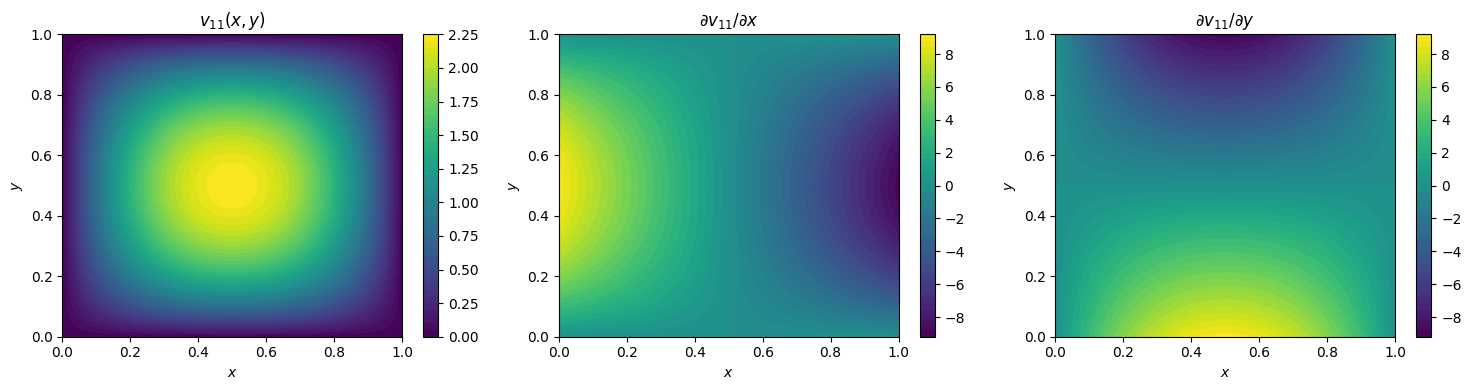

In [12]:
# Training setup

epochs = 1500   # number of epochs (training loops)
lr = 1e-3       # learning rate

# Define the neural network architecture
model_u = MLP([2, 64, 64, 64, 64, 1], dtype=torch.float32).to(device)

# Define number of test functions
N_test = 6
GetTest = test_function(N_test=N_test)

# Define loss object
lossClass = LossClass(model_u, N_test=N_test)

# Optimizer and learning rate scheduler
optimizer = torch.optim.Adam(params=model_u.parameters(), lr=lr, weight_decay=0)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=np.int32(epochs/4), gamma=0.5)

w_pde = 1.  # pde loss weight
w_bd = 50.  # boundary loss weight

# --- Prints ---

# Print Summary of the model
summary(model_u, input_size=(2,), device=str(device))

# Print first test function
n_plot = 100

x_axis = torch.linspace(0.0, 1.0, n_plot)
y_axis = torch.linspace(0.0, 1.0, n_plot)

X, Y = torch.meshgrid(x_axis, y_axis, indexing='ij')

# Shape: (n_plot**2, 2)
x_plot = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

# Shapes: (25, n_plot**2, 1) and (25, n_plot**2, 2)
v_all = GetTest.get_v(x_plot)
dv_all = GetTest.get_dv(x_plot)

# Choose the first mode pair: (m, n) = (1, 1)
mode_index = 0

v = v_all[mode_index].reshape(n_plot, n_plot).detach().cpu().numpy()

dv_dx = (dv_all[mode_index, :, 0].reshape(n_plot, n_plot).detach().cpu().numpy())

dv_dy = (dv_all[mode_index, :, 1].reshape(n_plot, n_plot).detach().cpu().numpy())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot0 = axes[0].contourf(X.numpy(), Y.numpy(), v, levels=50)
axes[0].set_title(r'$v_{11}(x,y)$')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$y$')
plt.colorbar(plot0, ax=axes[0])

plot1 = axes[1].contourf(X.numpy(), Y.numpy(), dv_dx, levels=50)
axes[1].set_title(r'$\partial v_{11}/\partial x$')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$y$')
plt.colorbar(plot1, ax=axes[1])

plot2 = axes[2].contourf(X.numpy(), Y.numpy(), dv_dy, levels=50)
axes[2].set_title(r'$\partial v_{11}/\partial y$')
axes[2].set_xlabel('$x$')
axes[2].set_ylabel('$y$')
plt.colorbar(plot2, ax=axes[2])

plt.tight_layout()
plt.show()

In [13]:
# Training Process

error_list = []
loss_list = []
loss_pde_list = []
loss_bd_list = []

model_u.train()

for epoch in trange(epochs):

    epoch_loss = 0.0
    epoch_pde_loss = 0.0
    epoch_bd_loss = 0.0

    for x_batch, mu_batch in dataLoader:

        optimizer.zero_grad()

        # Calculate mini-batch PDE loss
        loss_pde = lossClass.loss_pde(x_batch, mu_batch)

        # Boundary loss still uses all boundary points
        loss_bd = lossClass.loss_bd(x_bd, u_bd)

        # Total loss
        loss_train = w_pde * loss_pde + w_bd * loss_bd

        loss_train.backward()
        optimizer.step()

        epoch_loss += loss_train.item()
        epoch_pde_loss += loss_pde.item()
        epoch_bd_loss += loss_bd.item()

    scheduler.step()

    # Average losses over batches
    epoch_loss /= len(dataLoader)
    epoch_pde_loss /= len(dataLoader)
    epoch_bd_loss /= len(dataLoader)

    loss_list.append(epoch_loss)
    loss_pde_list.append(epoch_pde_loss)
    loss_bd_list.append(epoch_bd_loss)

    # Evaluate error after each epoch
    with torch.no_grad():
        error = lossClass.get_error(x_test, u_test)
        error_list.append(error.item())

    if (epoch + 1) % (epochs // 4) == 0:
        print(
            f'Epoch: {epoch+1}, '
            f'loss: {epoch_loss:.6e}, '
            f'loss_pde: {epoch_pde_loss:.6e}, '
            f'loss_bd: {epoch_bd_loss:.6e}, '
            f'error_u: {error_list[-1]:.6e}, '
            f'lr: {scheduler.optimizer.param_groups[0]["lr"]:.2e}'
        )

 25%|██▌       | 375/1500 [21:57<1:06:05,  3.52s/it]

Epoch: 375, loss: 4.475393e-01, loss_pde: 3.721181e-01, loss_bd: 1.508424e-03, error_u: 1.069536e-01, lr: 5.00e-04


 50%|█████     | 750/1500 [44:06<44:53,  3.59s/it]  

Epoch: 750, loss: 4.298856e-01, loss_pde: 3.942424e-01, loss_bd: 7.128647e-04, error_u: 8.675512e-02, lr: 2.50e-04


 75%|███████▌  | 1125/1500 [1:06:10<22:39,  3.62s/it]

Epoch: 1125, loss: 3.247841e-01, loss_pde: 3.000332e-01, loss_bd: 4.950174e-04, error_u: 8.890033e-02, lr: 1.25e-04


100%|██████████| 1500/1500 [1:31:14<00:00,  3.65s/it]

Epoch: 1500, loss: 2.680813e-01, loss_pde: 2.430712e-01, loss_bd: 5.002019e-04, error_u: 8.611780e-02, lr: 6.25e-05


### Visualization

In [14]:
# -----------------------------
# Prediction with trained model
# -----------------------------

model_u.eval()

with torch.no_grad():

    x_query = x_test.to(device)

    # Predict pressure u(x,y)
    u_query = model_u(x_query)

# Move everything to CPU / NumPy for plotting
x_plot = x_test.detach().cpu().numpy()
u_pred = u_query.detach().cpu().numpy()
u_ref = u_test.detach().cpu().numpy().reshape(-1, 1)

# Permeability field
mu_plot = mu_field.detach().cpu().numpy()

# Pointwise absolute error
u_error = np.abs(u_pred - u_ref)

# Reshape pressure fields back to 128 x 128 grids
u_pred_grid = u_pred.reshape(128, 128)
u_ref_grid = u_ref.reshape(128, 128)
u_error_grid = u_error.reshape(128, 128)

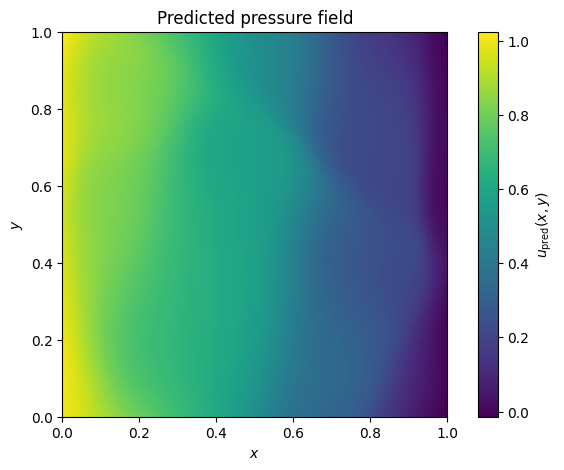

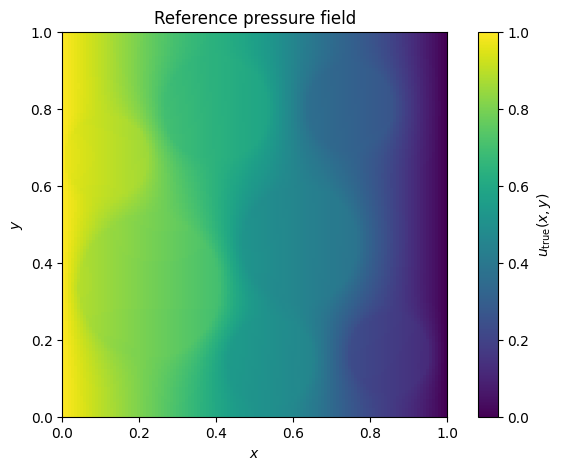

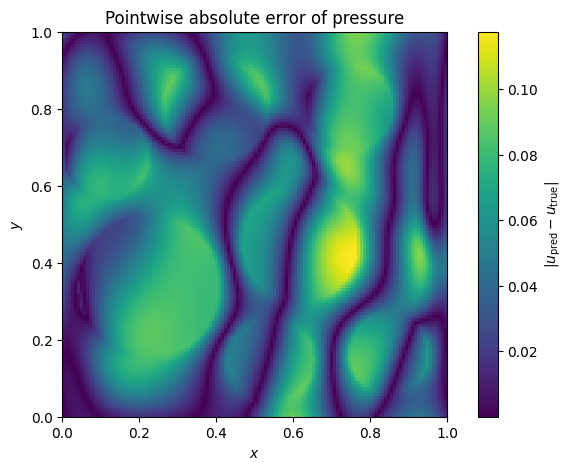

In [15]:
# -----------------------------
# Plot predicted pressure u_pred(x,y)
# -----------------------------

plt.figure(figsize=(8, 5))
plt.imshow(
    u_pred_grid,
    extent=[0, 1, 0, 1],
    origin='lower',
    aspect='equal'
)
plt.colorbar(label=r'$u_{\mathrm{pred}}(x,y)$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(r'Predicted pressure field')
plt.show()

# -----------------------------
# Plot reference pressure u_true(x,y)
# -----------------------------

plt.figure(figsize=(8, 5))
plt.imshow(
    u_ref_grid,
    extent=[0, 1, 0, 1],
    origin='lower',
    aspect='equal'
)
plt.colorbar(label=r'$u_{\mathrm{true}}(x,y)$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(r'Reference pressure field')
plt.show()

# -----------------------------
# Pointwise absolute error for u
# -----------------------------

plt.figure(figsize=(8, 5))
plt.imshow(
    u_error_grid,
    extent=[0, 1, 0, 1],
    origin='lower',
    aspect='equal'
)
plt.colorbar(label=r'$|u_{\mathrm{pred}} - u_{\mathrm{true}}|$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(r'Pointwise absolute error of pressure')
plt.show()

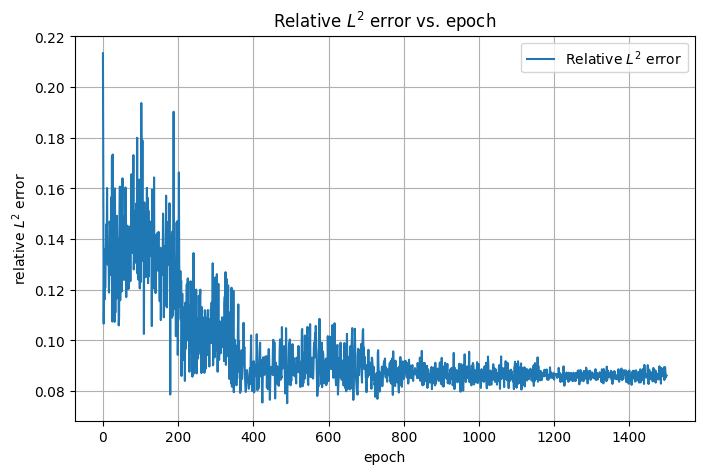

In [16]:
# -----------------------------
# Error vs. epoch
# -----------------------------

plt.figure(figsize=(8, 5))
plt.plot(error_list, label=r'Relative $L^2$ error')
plt.xlabel('epoch')
plt.ylabel(r'relative $L^2$ error')
plt.title(r'Relative $L^2$ error vs. epoch')
plt.legend()
plt.grid(True)
plt.show()